# Project Title:  HOME CREDIT DEFAULT RISK — Credit Scoring Project

## Description

 This dataset is from the Home Credit Default Risk competition hosted on Kaggle. Home Credit is an international constomers finance provider that focuses on lending to people with little or no credit history. 
 
**N/B** DAYS_EMPLOYED — Number of days before the application the person started their current job (negative value). Important anomaly: 365243 appears ~55,000 times and means the person is unemployed — not a real value. Must be replaced with NaN before modelling.

####  Goal:
Predict whether a loan applicant will default (fail to repay), using demographics, financial history, and external credit scores.

####  Problem Type: Binary Classification
TARGET = 1 -> Client had payment difficulties (defaulted)
TARGET = 0 -> Client repaid the loan without issues

####  Dataset Summary:
File             : application_train.csv
Total rows       : 307,511
Total columns    : 122
Numerical cols   : 106
Categorical cols : 16
Target column    : TARGET
Default rate     : ~8.1% (class imbalance)
Missing values   : Yes — several columns 60-70% missing
####  Evaluation Metric:
Because the dataset is imbalanced (91.9% non-default vs 8.1% default)we use AUC-ROC instead for evaluation.


##  COLUMN DESCRIPTIONS

##### 2.1 Identifier & Target ---
 SK_ID_CURR         : Unique loan application ID (not a feature)
 TARGET             : 1 = defaulted, 0 = repaid (target variable)

##### 2.2 Loan Information ---
NAME_CONTRACT_TYPE : Type of loan — Cash loans or Revolving loans

AMT_CREDIT         : Total loan amount approved

AMT_ANNUITY        : Annual loan repayment amount

AMT_GOODS_PRICE    : Price of goods the loan is for (if applicable)


##### 2.3 Applicant Demographics ---
CODE_GENDER        : Gender — M or F

 DAYS_BIRTH         : Age in days (negative). Convert: abs/365

 CNT_CHILDREN       : Number of children

 CNT_FAM_MEMBERS    : Total family members

 NAME_FAMILY_STATUS : Marital status — Single, Married, Divorced, etc.

 NAME_EDUCATION_TYPE: Education — Lower secondary to Academic degree

NAME_TYPE_SUITE    : Who accompanied applicant during application

NAME_HOUSING_TYPE  : Housing — House/apt, Rented, With parents, etc.
                                                              
#####  2.4 Financial Information ---
AMT_INCOME_TOTAL   : Annual income of the applicant

NAME_INCOME_TYPE   : Income source — Working, Pensioner, etc.

FLAG_OWN_CAR       : Owns a car — Y or N

FLAG_OWN_REALTY    : Owns real estate — Y or N

OWN_CAR_AGE        : Age of car in years (66% missing — car owners only)

OCCUPATION_TYPE    : Job type — Laborers, Managers, etc. (31% missing)

ORGANIZATION_TYPE  : Type of organization applicant works for

##### 2.5 External Credit Scores (most predictive features) ---
EXT_SOURCE_1       : External credit score source 1 (0-1, 56% missing)

EXT_SOURCE_2       : External credit score source 2 (0-1, few missing)

EXT_SOURCE_3       : External credit score source 3 (0-1, 20% missing)

##### 2.6 Days / Time-Based Features (all negative = days before application) ---
DAYS_EMPLOYED      : Days since current job started. 365243 = unemployed (anomaly)

DAYS_REGISTRATION  : Days since documents were registered

DAYS_ID_PUBLISH    : Days since ID was published/renewed

DAYS_LAST_PHONE_CHANGE: Days since phone number last changed

WEEKDAY_APPR_PROCESS_START: Day of week application was started

HOUR_APPR_PROCESS_START   : Hour of the day application was started

##### 2.7 Region & Address Flags ---
REGION_POPULATION_RELATIVE     : Normalised population of applicant's region

REGION_RATING_CLIENT           : Home Credit region risk rating (1-3)

REGION_RATING_CLIENT_W_CITY    : Same but accounting for city
                                                    
REG_REGION_NOT_LIVE_REGION     : 1 if registered region != living region

REG_REGION_NOT_WORK_REGION     : 1 if registered region != work region

LIVE_REGION_NOT_WORK_REGION    : 1 if living region != work region

REG_CITY_NOT_LIVE_CITY         : 1 if registered city != living city

REG_CITY_NOT_WORK_CITY         : 1 if registered city != work city

LIVE_CITY_NOT_WORK_CITY        : 1 if living city != work city

##### 2.8 Contact / Social Circle ---
FLAG_MOBIL         : Provided mobile phone (almost all 1, low value)

FLAG_EMP_PHONE     : Provided work phone

FLAG_WORK_PHONE    : Provided work phone number

FLAG_CONT_MOBILE   : Mobile was reachable

FLAG_PHONE         : Provided home phone

FLAG_EMAIL         : Provided email address

OBS_30_CNT_SOCIAL_CIRCLE : Social circle observed for 30-day default

DEF_30_CNT_SOCIAL_CIRCLE : Social circle who defaulted at 30 days

OBS_60_CNT_SOCIAL_CIRCLE : Same, 60-day DPD

DEF_60_CNT_SOCIAL_CIRCLE : Social circle who defaulted at 60 days

##### 2.9 Building / Property Features ---
45+ columns (APARTMENTS_*, BASEMENTAREA_*, FLOORSMAX_*, etc.) Each comes in 3 versions: AVG, MODE, MEDIAN Most have 50-70% missing — mostly property/building stats

##### 2.10 Document Flags ---
FLAG_DOCUMENT_2 to FLAG_DOCUMENT_21

Binary — whether applicant submitted each document, Most have near-zero variance and low predictive value

##### 2.11 Credit Bureau Enquiry Counts ---
AMT_REQ_CREDIT_BUREAU_HOUR  : Credit checks in last hour

AMT_REQ_CREDIT_BUREAU_DAY   : Credit checks in last day

AMT_REQ_CREDIT_BUREAU_WEEK  : Credit checks in last week

AMT_REQ_CREDIT_BUREAU_MON   : Credit checks in last month

AMT_REQ_CREDIT_BUREAU_QRT   : Credit checks in last quarter

AMT_REQ_CREDIT_BUREAU_YEAR  : Credit checks in last year

In [1]:
#SETUP, IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

In [2]:
df = pd.read_csv(r"C:\Users\HP\Downloads\archive (10)\application_train.csv")
# Show all columns
pd.set_option('display.max_columns', None)
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
df.duplicated().sum()

0

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [6]:
df.isnull().sum().sum()

9152465

IMAGINE SEE THE KIND OF MISSING VALUES PRESENT IN THIS DATASET!! LET START DATA CLEANING

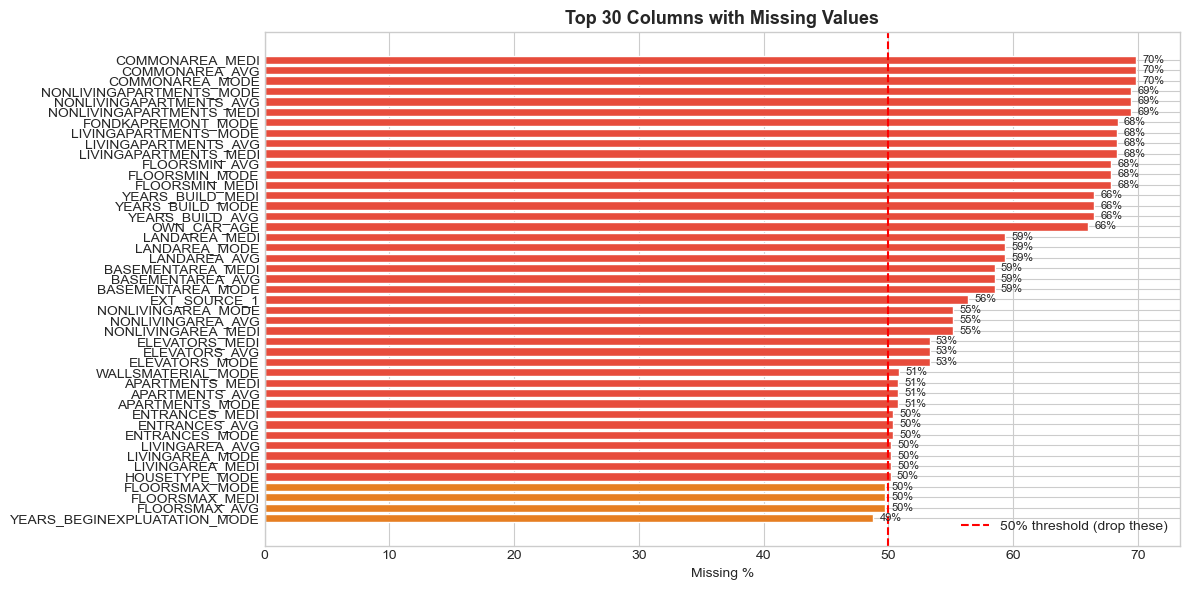

Red bars = drop them with 50% threshold. Orange = impute with mode carefully. Yellow = median impute.


In [7]:
#pre-cleaning diagnostic chart, to be sure of the columns to drop
fig, ax = plt.subplots(figsize=(12, 6))

missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0].head(45)

colors_missing = ['#E74C3C' if v > 50 else '#E67E22' if v > 20 else '#F1C40F'for v in missing_pct.values]

bars = ax.barh(missing_pct.index[::-1], missing_pct.values[::-1],color=colors_missing[::-1], edgecolor='white')
ax.set_title('Top 30 Columns with Missing Values', fontsize=13, fontweight='bold')
ax.set_xlabel('Missing %')
ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50% threshold (drop these)')
ax.legend()

for bar, val in zip(bars, missing_pct.values[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,f'{val:.0f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('viz_08_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Red bars = drop them with 50% threshold. Orange = impute with mode carefully. Yellow = median impute.")


##### DATA CLEANING

In [8]:
# drop all columns with more than 50% missing values
col_to_drop = df.columns[df.isnull().mean() > 0.5].tolist() 
df = df.drop(columns=col_to_drop)
print(f' Shape after dropping: {df.shape}')

 Shape after dropping: (307511, 81)


Since it was mentioned in the description that DAYS_EMPLOYED COLUMN HAS Important anomaly: 365243 appears ~55,000 times and means the person is unemployed — not a real value. Must be replaced with NaN before modelling. so we start with that first.

In [9]:
# Fix the DAYS_EMPLOYED anomaly
print(f'DAYS_EMPLOYED anomaly count: {(df['DAYS_EMPLOYED']== 365243).sum()}')

DAYS_EMPLOYED anomaly count: 55374


In [10]:
print((df['DAYS_EMPLOYED']== 365243).dtype)

bool


In [11]:
#the result will be an interger i.e 1 $ 0 not True and False 
df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
print(f'anomaly flag created. NAN count: {df['DAYS_EMPLOYED'].isnull().sum()}')

anomaly flag created. NAN count: 55374


In [12]:
# filling the remaining columns that has missing values
#numerical column: fill with median since there are multiply column here, it has extreme outlier.
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
print(f' All the numerical columns in this dataset are:  {len(num_cols)}')

 All the numerical columns in this dataset are:  69


In [13]:
#categorical columns: fill with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print(f'All the catergorical column in this dataset are: {len(cat_cols)}') 

All the catergorical column in this dataset are: 13


In [14]:
print(f'Missing values after filling: {df.isnull().sum().sum()}')

Missing values after filling: 0


In [15]:
#drop all the flag columns with low variance but let's print out the flag document first
doc_cols = []
for col in df.columns:
    if 'FLAG_DOCUMENT' in col:
        doc_cols.append(col)
print(doc_cols)        

['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']


In [16]:
doc_var = df[doc_cols].var().sort_values()
#drop column where variance is less than 0.01
low_var_docs = doc_var[doc_var<0.01].index.tolist()
df = df.drop(columns=low_var_docs)
print(f'Number of flag_document columns with low variance is: {len(low_var_docs)} columns')
df

Number of flag_document columns with low variance is: 16 columns


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_3,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_8,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_ANOMALY
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637.0,-3648.0,-2120,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.262949,0.139376,0.9722,0.0833,0.9722,0.0833,0.9722,0.0833,0.0149,No,2.0,2.0,2.0,2.0,-1134.0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188.0,-1186.0,-291,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.622246,0.535276,0.9851,0.2917,0.9851,0.2917,0.9851,0.2917,0.0714,No,1.0,0.0,1.0,0.0,-828.0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225.0,-4260.0,-2531,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.555912,0.729567,0.9816,0.1667,0.9816,0.1667,0.9816,0.1667,0.0688,No,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039.0,-9833.0,-2437,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,0.650442,0.535276,0.9816,0.1667,0.9816,0.1667,0.9816,0.1667,0.0688,No,2.0,0.0,2.0,0.0,-617.0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038.0,-4311.0,-3458,1,1,0,1,0,0,Core staff,1.0,2,2,THURSDAY,11,0,0,0,0,1,1,Religion,0.322738,0.535276,0.9816,0.1667,0.9816,0.1667,0.9816,0.1667,0.0688,No,0.0,0.0,0.0,0.0,-1106.0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,Unaccompanied,Working,Secondary / secondary special,Separated,With parents,0.032561,-9327,-236.0,-8456.0,-1982,1,1,0,1,0,0,Sales staff,1.0,1,1,THURSDAY,15,0,0,0,0,0,0,Services,0.681632,0.535276,0.9876,0.6042,0.9782,0.4583,0.9876,0.6042,0.2898,No,0.0,0.0,0.0,0.0,-273.0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,1.0,0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,0.025164,-20775,-1648.0,-4388.0,

In [17]:
#check for outliers and cap them
num_cols = df.select_dtypes(include='number').columns.drop('TARGET')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lowerbound = Q1 - 1.5*IQR
    upperbound = Q3 + 1.5*IQR
    outliers = df[(df[col]<  lowerbound ) | (df[col]>upperbound)]
    if len(outliers)>0:
        print(f'{col}: {len(outliers):,} outliers ({len(outliers)/len(df):.1%})')

CNT_CHILDREN: 4,272 outliers (1.4%)
AMT_INCOME_TOTAL: 14,035 outliers (4.6%)
AMT_CREDIT: 6,562 outliers (2.1%)
AMT_ANNUITY: 7,504 outliers (2.4%)
AMT_GOODS_PRICE: 14,728 outliers (4.8%)
REGION_POPULATION_RELATIVE: 8,412 outliers (2.7%)
DAYS_EMPLOYED: 23,148 outliers (7.5%)
DAYS_REGISTRATION: 659 outliers (0.2%)
FLAG_MOBIL: 1 outliers (0.0%)
FLAG_EMP_PHONE: 55,386 outliers (18.0%)
FLAG_WORK_PHONE: 61,308 outliers (19.9%)
FLAG_CONT_MOBILE: 574 outliers (0.2%)
FLAG_EMAIL: 17,442 outliers (5.7%)
CNT_FAM_MEMBERS: 4,007 outliers (1.3%)
REGION_RATING_CLIENT: 80,527 outliers (26.2%)
REGION_RATING_CLIENT_W_CITY: 78,027 outliers (25.4%)
HOUR_APPR_PROCESS_START: 2,257 outliers (0.7%)
REG_REGION_NOT_LIVE_REGION: 4,657 outliers (1.5%)
REG_REGION_NOT_WORK_REGION: 15,612 outliers (5.1%)
LIVE_REGION_NOT_WORK_REGION: 12,503 outliers (4.1%)
REG_CITY_NOT_LIVE_CITY: 24,039 outliers (7.8%)
REG_CITY_NOT_WORK_CITY: 70,867 outliers (23.0%)
LIVE_CITY_NOT_WORK_CITY: 55,215 outliers (18.0%)
EXT_SOURCE_3: 4,313 o

In [18]:
num_col = df.select_dtypes(include='number').columns.drop('TARGET')
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lowerbound = Q1 - 1.5*IQR
    upperbound = Q3 + 1.5*IQR
    df[col] = df[col].clip(lowerbound,upperbound)
    print(f'{col}: {len(outliers)} outerliers ({len(outliers)/len(df):.1%})')
print(f'final rows remaining after all column cleaned is:{len(df)}')

SK_ID_CURR: 55374 outerliers (18.0%)
CNT_CHILDREN: 55374 outerliers (18.0%)
AMT_INCOME_TOTAL: 55374 outerliers (18.0%)
AMT_CREDIT: 55374 outerliers (18.0%)
AMT_ANNUITY: 55374 outerliers (18.0%)
AMT_GOODS_PRICE: 55374 outerliers (18.0%)
REGION_POPULATION_RELATIVE: 55374 outerliers (18.0%)
DAYS_BIRTH: 55374 outerliers (18.0%)
DAYS_EMPLOYED: 55374 outerliers (18.0%)
DAYS_REGISTRATION: 55374 outerliers (18.0%)
DAYS_ID_PUBLISH: 55374 outerliers (18.0%)
FLAG_MOBIL: 55374 outerliers (18.0%)
FLAG_EMP_PHONE: 55374 outerliers (18.0%)
FLAG_WORK_PHONE: 55374 outerliers (18.0%)
FLAG_CONT_MOBILE: 55374 outerliers (18.0%)
FLAG_PHONE: 55374 outerliers (18.0%)
FLAG_EMAIL: 55374 outerliers (18.0%)
CNT_FAM_MEMBERS: 55374 outerliers (18.0%)
REGION_RATING_CLIENT: 55374 outerliers (18.0%)
REGION_RATING_CLIENT_W_CITY: 55374 outerliers (18.0%)
HOUR_APPR_PROCESS_START: 55374 outerliers (18.0%)
REG_REGION_NOT_LIVE_REGION: 55374 outerliers (18.0%)
REG_REGION_NOT_WORK_REGION: 55374 outerliers (18.0%)
LIVE_REGION_

#### Data Visualization Or EDA

In [19]:
df['AGE_YEARS'] = (-df['DAYS_BIRTH']/365).astype(int)
df['DAYS_EMPLOYED_CLEAN'] = (-df['DAYS_EMPLOYED']/365).astype(int)
df['YEARS_EMPLOYED'] = (-df['DAYS_EMPLOYED']/365).astype(int)
df['YEARS_REGISTRATION'] =(-df['DAYS_REGISTRATION']/365).astype(int)
df['YEARS_ID_PUBLISH'] = (-df['DAYS_ID_PUBLISH']/365).astype(int)
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT']/df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY']/df['AMT_INCOME_TOTAL']
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_2',	'EXT_SOURCE_3']].mean(axis=1)
df = df.drop(columns=['DAYS_BIRTH','DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH'])  
print('Data is ready for visualization')
print(f'After adding an extra columns to it, the shape is now: {df.shape}')

Data is ready for visualization
After adding an extra columns to it, the shape is now: (307511, 70)


In [20]:
#count for Target column
counts = df['TARGET'].value_counts()
percentage = (counts /len(df))*100
for value in counts.index:
    print(f'TARGET {value}: {counts[value]} ({percentage[value]:.1f}%)')

TARGET 0: 282686 (91.9%)
TARGET 1: 24825 (8.1%)


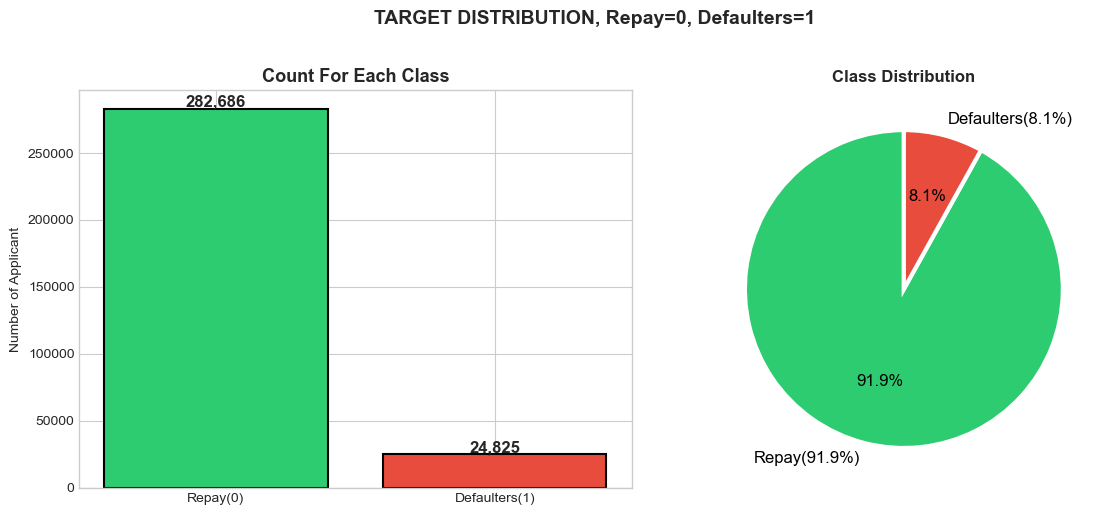

Dataset is inbalanced


In [21]:
#Target Distribution
#bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('TARGET DISTRIBUTION, Repay=0, Defaulters=1', fontsize=14, fontweight='bold', y=1.02)
target_counts = df['TARGET'].value_counts()
colors = ['#2ECC71', '#E74C3C']
#bar chart
bars = axes[0].bar(['Repay(0)', 'Defaulters(1)'], target_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_title('Count For Each Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Applicant')
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() +bar.get_width()/2, bar.get_height() + 2000, f'{val:,}',
                 ha='center', fontsize=12, fontweight='bold')
#pie plot
axes[1].pie(target_counts.values, colors=colors, wedgeprops= {'edgecolor':'white', 'linewidth':3}, textprops = {'fontsize': 12, 'color': 'black'},
            startangle = 90, autopct='%1.1f%%', labels=['Repay(91.9%)', 'Defaulters(8.1%)'])
axes[1].set_title('Class Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('Dataset is inbalanced')

**INSIGHT GOTTEN FROM THIS VISUALIZATION IS**: The green bar shows repay while the red bar shows defaulters, that means only few of the applicant default but most of the applicant repay their loan.  

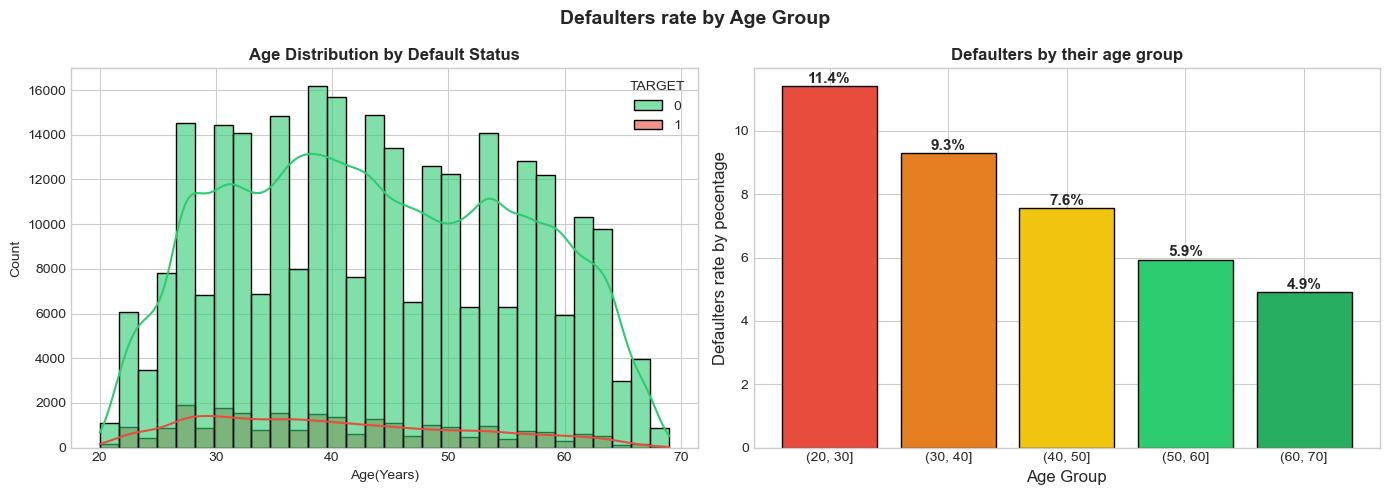

<Figure size 640x480 with 0 Axes>

In [22]:
#check for age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle ('Defaulters rate by Age Group', fontsize=14, fontweight='bold')
sns.histplot(data=df, x='AGE_YEARS', hue='TARGET', bins=30, alpha=0.6, ax=axes[0], palette={1:'#E74C3C', 0:'#2ECC71'}, kde=True)
axes[0].set_title('Age Distribution by Default Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age(Years)')
axes[0].set_ylabel('Count')
plt.legend()

#check defaulters by age bin
Age_bin = pd.cut(df['AGE_YEARS'], bins=[20,30,40,50,60,70])
defaulters_by_age=df.groupby(Age_bin)['TARGET'].mean()*100
bars=axes[1].bar([str(x) for x in defaulters_by_age.index], defaulters_by_age.values, color=['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#27AE60'],edgecolor='black')
axes[1].set_title('Defaulters by their age group', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Defaulters rate by pecentage', fontsize=12)
axes[1].set_xlabel('Age Group', fontsize=12)
for bar, val in zip(bars, defaulters_by_age.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig('viz_02_defaulters_by_age_analysis.png', dpi=150, facecolor='white', bbox_inches='tight',transparent=False)

**INSIGHT GOTTEN FROM THIS VISUALIZATION IS**: The histogram on the left confirms that the red bins is almost flat and it is a bit higher on the left than on the right meaning that there are few number of defaulters while the green dominate showing that a good number of people repay their loan, the bar chart shows that younger people from age 20-30 are more dangerous to give loan with 11.4% of them default. Older people from age 60-70 are safer to give loan with 4.9% default. So a bank looking at this should be more cautious lending loans to younger people under 30 and be confident with older people above 50.

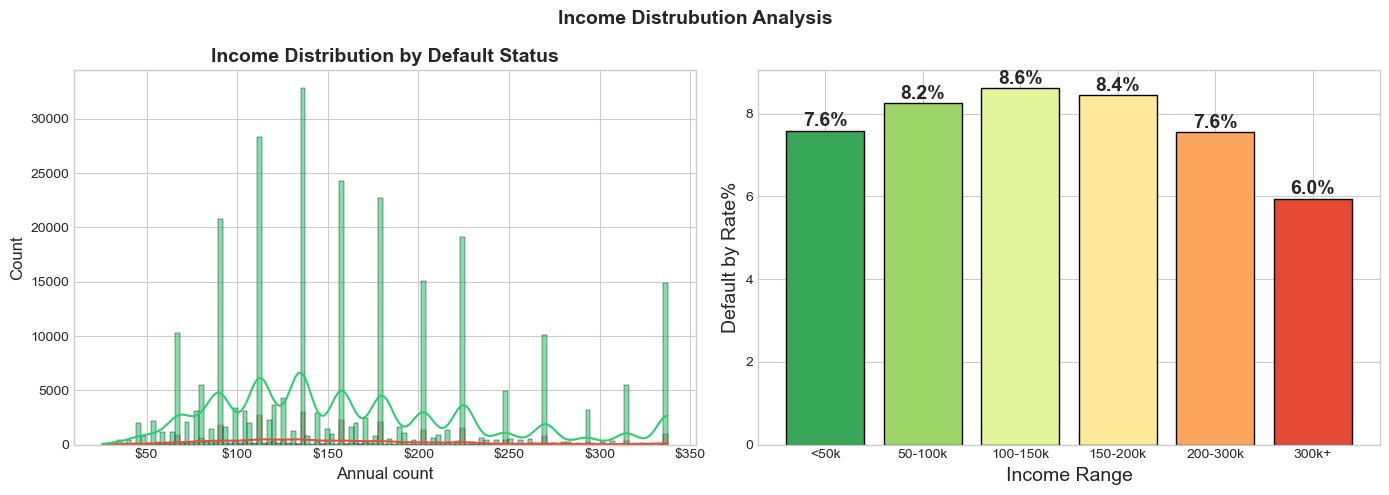

In [23]:
import matplotlib.ticker as mticker
# income distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Income Distrubution Analysis', fontsize = 14, fontweight='bold')
sns.histplot(data=df, x='AMT_INCOME_TOTAL', hue='TARGET', alpha=0.6, kde=True, palette={1:'#E74C3C', 0:'#2ECC71'}, ax=axes[0])
axes[0].set_title('Income Distribution by Default Status', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xlabel('Annual count', fontsize=12)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}'))
axes[0].legend()

#Defaulters by income bracket
income_bin = pd.cut(df['AMT_INCOME_TOTAL'],  bins=[0, 50000, 100000, 150000, 200000, 300000, 9999999],
                     labels=['<50k', '50-100k', '100-150k', '150-200k', '200-300k', '300k+'])
defaulters_by_income = df.groupby(income_bin)['TARGET'].mean()*100
axes[1].bar(defaulters_by_income.index, defaulters_by_income.values, color=sns.color_palette('RdYlGn_r', len(defaulters_by_income)), edgecolor='black')
axes[1].set_ylabel('Default by Rate%', fontsize=14)
axes[1].set_xlabel('Income Range', fontsize=14)
for j, val in enumerate(defaulters_by_income.values):
    axes[1].text(j, val+ 0.1, f'{val:.1f}%', ha='center', fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.savefig('viz_03_income_analysis.png', dpi=150, facecolor='white', bbox_inches='tight',transparent=False)
plt.show()


**INSIGHT GOTTEN FROM THIS VISUALIZATION IS**: The bars explains that the richest people 300k+ default the least with 6.0% because they have money to repay, the poor with <50k default with 7.6% but suprisingly, the middle income group with 100k-150k default the most with 8.6%. The conclusion is that many people are taking loans that they cannot afford, thinking that they earn enough but simply overstretching themselves, then the defaulters does not depend if they are rich or poor.

In [24]:
#check for name_education_type unique.
df['NAME_EDUCATION_TYPE'].unique().tolist()

['Secondary / secondary special',
 'Higher education',
 'Incomplete higher',
 'Lower secondary',
 'Academic degree']

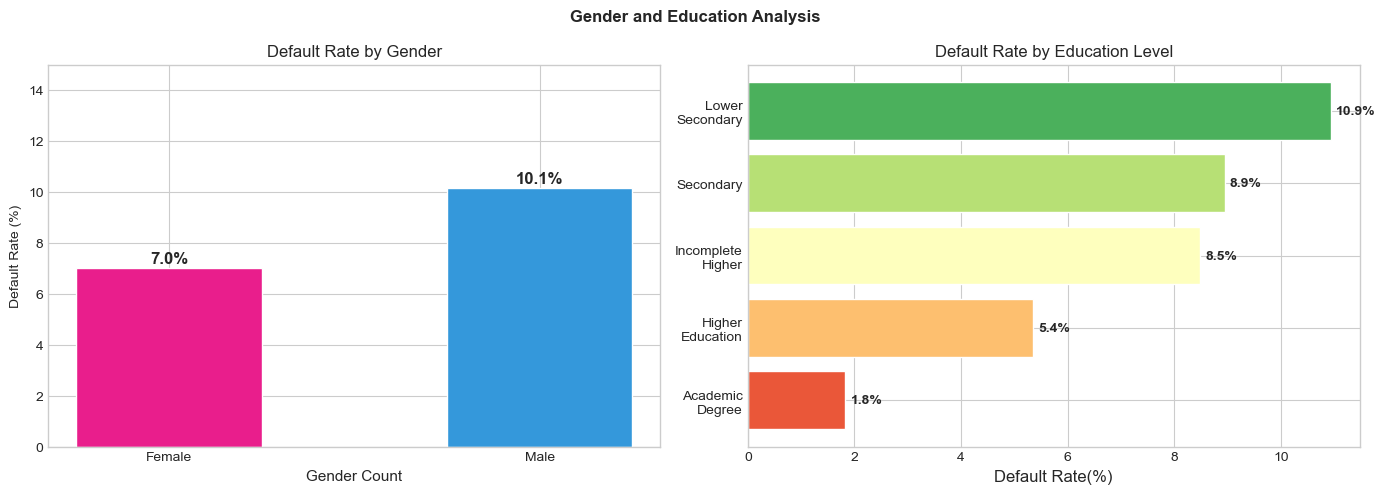

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64


In [25]:
#Default rate by gender and education
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gender and Education Analysis', fontsize=12, fontweight='bold')

gender_data = df[df['CODE_GENDER']!='XNA']
gender_default = gender_data.groupby('CODE_GENDER')['TARGET'].mean()*100
gender_counts = gender_data['CODE_GENDER'].value_counts()
gender_labels = [f'{'Female' if g =='F' else 'Male'}' for g in gender_default.index]
bars = axes[0].bar(gender_labels, gender_default.values, color=['#E91E8C', '#3498DB'], edgecolor='white', width=0.5)
axes[0].set_title('Default Rate by Gender', fontsize=12)
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_xlabel('Gender Count', fontsize=11)
axes[0].set_ylim(0, 15)
for bar, val in zip(bars, gender_default.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

#Education
edu_default = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean()*100
edu_default = edu_default.sort_values(ascending=True)
edu_labels = {
    'Secondary / secondary special':'Secondary',
    'Higher education':'Higher\nEducation',
    'Incomplete higher':'Incomplete\nHigher',
    'Lower secondary':'Lower\nSecondary',
    'Academic degree':'Academic\nDegree'}
labels = [edu_labels.get(x, x) for x in edu_default.index]
colors_edu = sns.color_palette('RdYlGn', len(edu_default))
bars2 =axes[1].barh(labels, edu_default.values, color=colors_edu, edgecolor='white')
axes[1].set_title('Default Rate by Education Level', fontsize=12)
axes[1].set_xlabel('Default Rate(%)', fontsize=12)
for bar, val in zip(bars2, edu_default.values):
    axes[1].text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('gender_educationa_visualization', dpi=150, bbox_inches='tight')
plt.show()
print(df['CODE_GENDER'].value_counts())

**INSIGHT GOTTEN FROM THIS VISUALIZATION IS**: The first chart says that male default more than female even though female are more than male in number.Females are more financially responsible on average when it comes to loan repayment and the second chart says that the more educated a person is, the less likely to default, i.e people with lower education level default more than people with higher education level

In [26]:
# Default by employment Status
df['NAME_INCOME_TYPE'].unique().tolist()

['Working',
 'State servant',
 'Commercial associate',
 'Pensioner',
 'Unemployed',
 'Student',
 'Businessman',
 'Maternity leave']

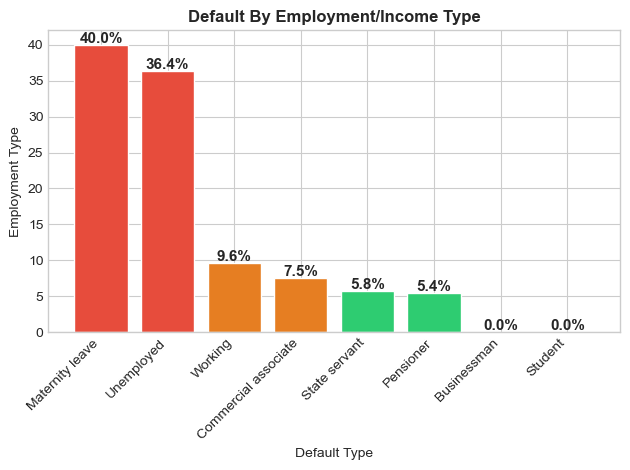

In [27]:
fig, ax = plt.subplots(figure=(14, 14))
emp_default = df.groupby('NAME_INCOME_TYPE')['TARGET'].mean()*100
emp_default = emp_default.sort_values(ascending=False)
colors_emp = ['#E74C3C' if v >10 else '#E67E22' if v > 7 else '#2ECC71' for v in emp_default.values]
bars = ax.bar(emp_default.index, emp_default.values, color= colors_emp, edgecolor='white')
ax.set_title('Default By Employment/Income Type', fontsize=12,fontweight='bold')
ax.set_ylabel('Employment Type')
ax.set_xlabel('Default Type')
ax.set_xticklabels(emp_default.index, rotation=45, ha='right')
for bar, val in zip(bars, emp_default.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_05_employment_status.png', dpi=150, bbox_inches='tight')
plt.show()

**INSIGHT GOTTEN FROM THIS VISUALIZATION IS**: This chart says that people on maternity leave default most and unemployed people but student and businessmen do not default at all

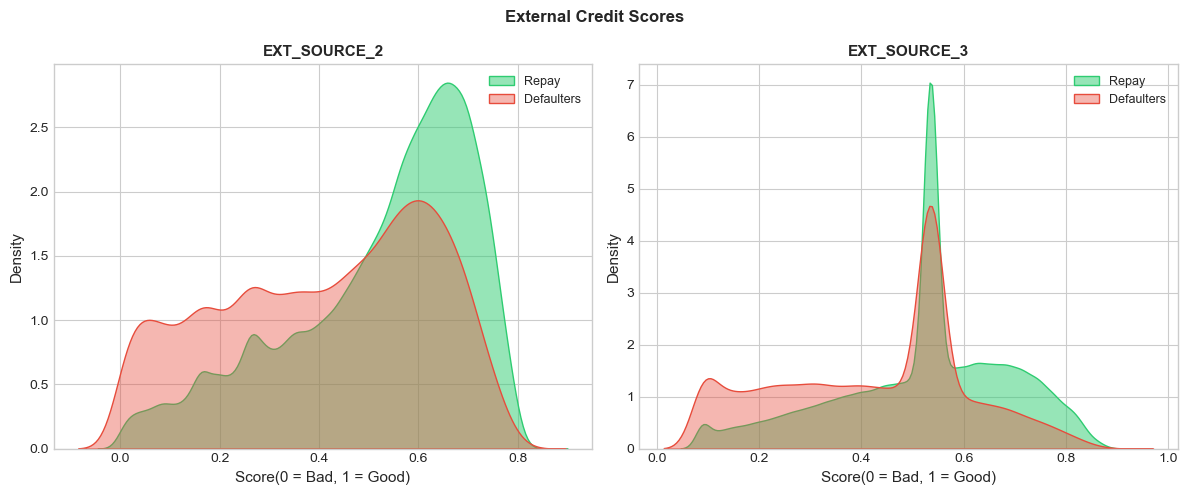

<Figure size 640x480 with 0 Axes>

In [28]:
# External credit score distributions (most powerful features)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('External Credit Scores', fontsize=12, fontweight='bold')
for i, col in enumerate([ 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    sns.kdeplot(data=df[df['TARGET']==0][col], ax=axes[i], alpha=0.5, color='#2ECC71', label='Repay', fill=True)
    sns.kdeplot(data=df[df['TARGET']==1][col], ax=axes[i],  alpha=0.4, color='#E74C3C', label='Defaulters', fill=True)
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Density', fontsize=11)
    axes[i].set_xlabel('Score(0 = Bad, 1 = Good)', fontsize=11)
    axes[i].legend(fontsize=9)
plt.tight_layout()
plt.show()
plt.savefig('viz_06_ext_sources.png', dpi=150, bbox_inches='tight')      

**INSIGHT GOTTEN FROM THIS VISUALIZATION IS**:Ext_scorce2 shows that customers with good credit score with 6.0 - 8.0 in the green curve, are likely to repay their loan while while those with lower score form 0.0-0.5 are defaulters. the second chart spikes around 0.5 for both group that means both group were assign the same score in the dataset.

In [29]:
 'CREDIT_INCOME_RATIO' in df.columns

True

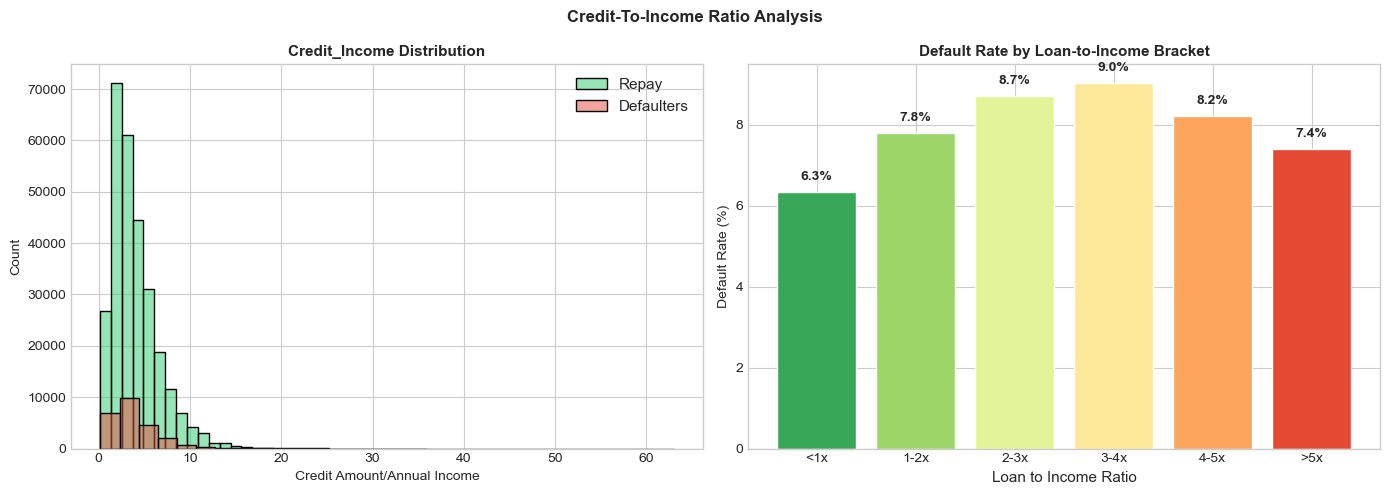

In [30]:
#Credit-to-income ratio analysis
# Credit-to-income ratio analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Credit-To-Income Ratio Analysis', fontsize=12, fontweight='bold')

# Left chart - both repay and defaulters on same axes[0]
sns.histplot(data=df[df['TARGET']==0]['CREDIT_INCOME_RATIO'], ax=axes[0], bins=30, alpha=0.5, color='#2ECC71', label='Repay')
sns.histplot(data=df[df['TARGET']==1]['CREDIT_INCOME_RATIO'], ax=axes[0], bins=30, alpha=0.5, color='#E74C3C', label='Defaulters')
axes[0].set_title('Credit_Income Distribution', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Credit Amount/Annual Income')
axes[0].legend(fontsize=11)

# Right chart - default rate by ratio bracket
ratio_bin = pd.cut(df['CREDIT_INCOME_RATIO'], bins=[0,1,2,3,4,5,100], labels=['<1x', '1-2x', '2-3x', '3-4x', '4-5x', '>5x'])
ratio_default = df.groupby(ratio_bin, observed=True)['TARGET'].mean() * 100
axes[1].bar(ratio_default.index, ratio_default.values, color=sns.color_palette('RdYlGn_r', len(ratio_default)), edgecolor='white')
axes[1].set_title('Default Rate by Loan-to-Income Bracket', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Loan to Income Ratio', fontsize=11)
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', labelsize=10)

for i, val in enumerate(ratio_default.values):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**INSIGHT GOTTEN FROM THIS VISUALIZATION IS**:The first chart shows that are few defaulters that range from 0-10 but the people tha pays back dominate across all levels in the chart, while the second chart shows that the mid-range earners at 3-4x default more with 9.0% or earners from 2-4x default most 

In [31]:
#Housing Type & Contract Type
df['NAME_HOUSING_TYPE'].unique().tolist()

['House / apartment',
 'Rented apartment',
 'With parents',
 'Municipal apartment',
 'Office apartment',
 'Co-op apartment']

In [32]:
df['NAME_CONTRACT_TYPE'].unique().tolist()

['Cash loans', 'Revolving loans']

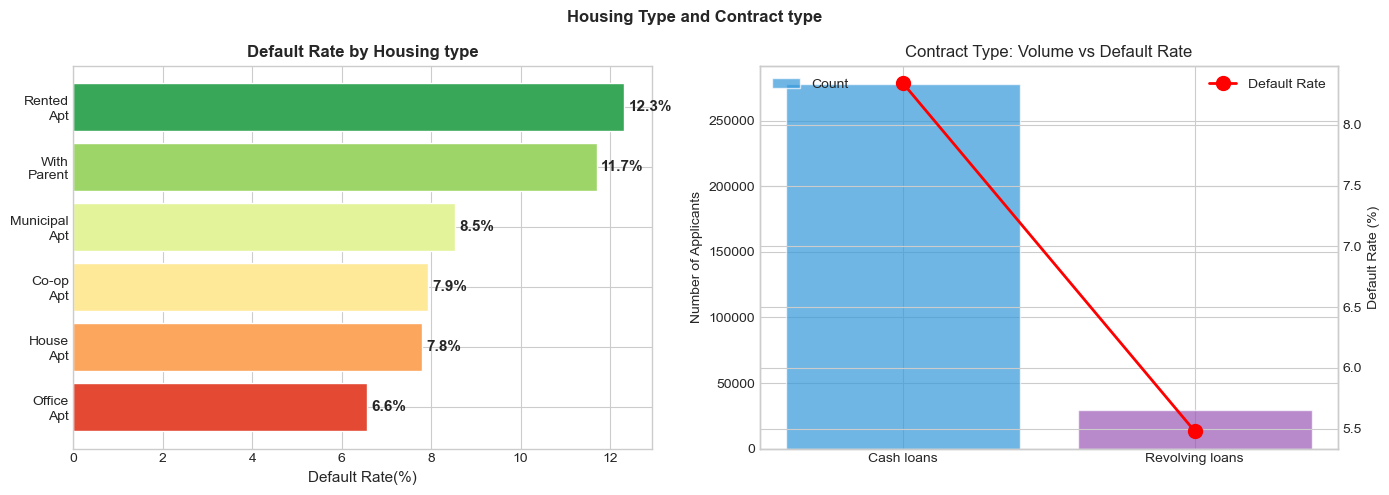

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Housing Type and Contract type', fontsize=12, fontweight='bold')
housing_default =df.groupby('NAME_HOUSING_TYPE')['TARGET'].mean()*100
housing_default = housing_default.sort_values(ascending=True)
housing_labels = {
    'House / apartment':'House\nApt',
    'Rented apartment':'Rented\nApt',
    'With parents':'With\nParent',
    'Municipal apartment':'Municipal\nApt',
    'Office apartment':'Office\nApt',
    'Co-op apartment':'Co-op\nApt'
}
labels_h = [housing_labels.get(x, x)for x in housing_default.index]
color_housing = sns.color_palette('RdYlGn', len(housing_default))
bar1 = axes[0].barh(labels_h, housing_default.values, color=color_housing, edgecolor='white')
axes[0].set_title('Default Rate by Housing type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Default Rate(%)', fontsize=11)
for bar, val in zip(bar1, housing_default.values):
    axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')


# Contract type
contract_data = df.groupby('NAME_CONTRACT_TYPE').agg(count=('TARGET', 'count'),default_rate=('TARGET', 'mean')).reset_index()
contract_data['default_rate'] *= 100

x = range(len(contract_data))
ax2 = axes[1]
ax2_right = ax2.twinx()
bars2 = ax2.bar(x, contract_data['count'], color=['#3498DB', '#9B59B6'],alpha=0.7, edgecolor='white', label='Count')
line = ax2_right.plot(x, contract_data['default_rate'], 'ro-', linewidth=2, markersize=10, label='Default Rate')
ax2.set_xticks(list(x))
ax2.set_xticklabels(contract_data['NAME_CONTRACT_TYPE'])
ax2.set_title('Contract Type: Volume vs Default Rate', fontsize=12)
ax2.set_ylabel('Number of Applicants')
ax2_right.set_ylabel('Default Rate (%)')
ax2.legend(loc='upper left')
ax2_right.legend(loc='upper right')

plt.tight_layout()
plt.savefig('viz_09_housing_contract.png', dpi=150, bbox_inches='tight')
plt.show()

**INSIGHT GOTTEN FROM THIS VISUALIZATION IS**: For the first chat, the renters and those staying with their parent have the highest default risk because they are not finanically unstable and house owners and office apt are have less default risk because they are financially stable. The second chart shows that applicant with revolving loan are financially experienced because of that they have low default rate compared to cash loan which have high default rate. 

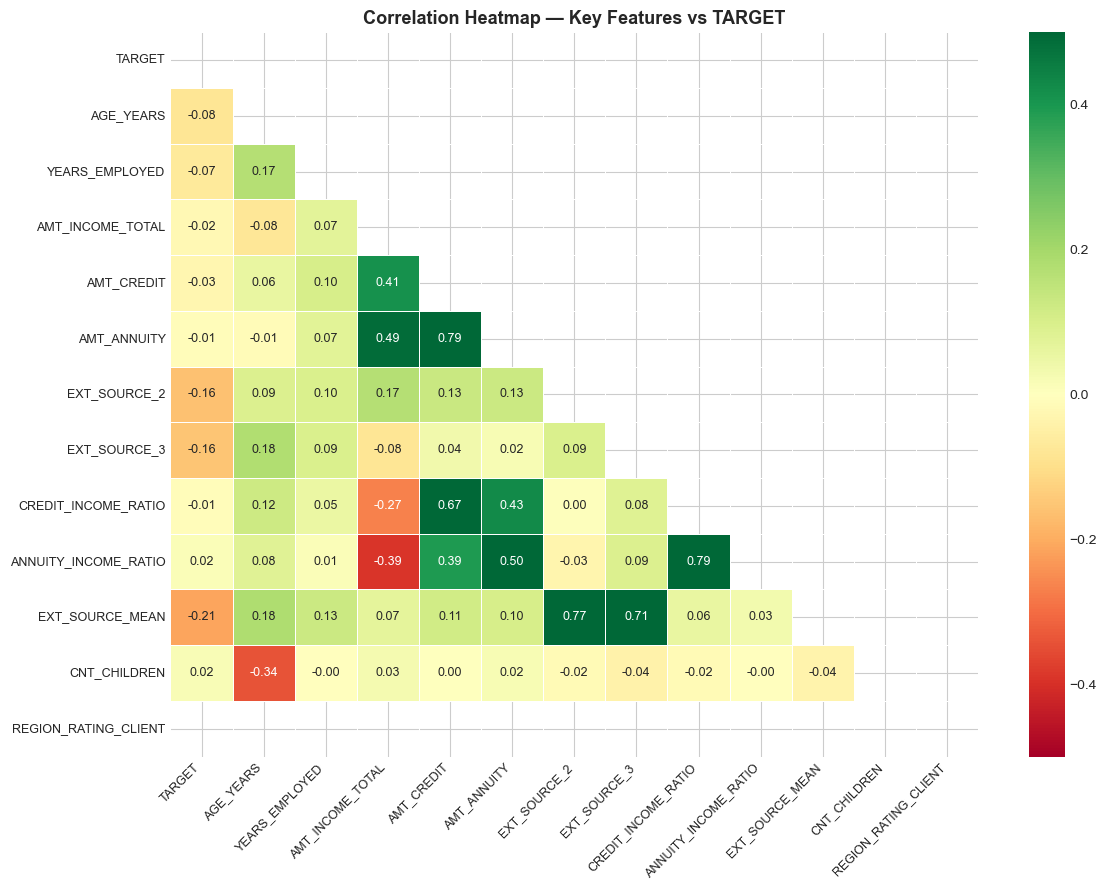

In [34]:
# Correlation heatmap 
key_features = [
    'TARGET', 'AGE_YEARS', 'YEARS_EMPLOYED', 'AMT_INCOME_TOTAL','AMT_CREDIT', 'AMT_ANNUITY', 'EXT_SOURCE_2','EXT_SOURCE_3', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
    'EXT_SOURCE_MEAN', 'CNT_CHILDREN', 'REGION_RATING_CLIENT'
]

corr_df = df[key_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_df, dtype=bool))  # Show only lower triangle

sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.5, ax=ax, linewidths=0.5, linecolor='white', annot_kws={'size': 9})

ax.set_title('Correlation Heatmap — Key Features vs TARGET', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9, va='center')
plt.tight_layout()
plt.savefig('viz_10_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**INSIGHT GOTTEN FROM THIS VISUALIZATION IS**: From the heatmap, the strongest predictor to the target is  EXT_SOURCE_MEAN with 0.21 and EXT_SOURCE 1 & 2 while the lowest predictor is credit income ratio and amt_annuity with -0.01 to the target.

### Feature Engineering

In [35]:
# how much are they borrowing vs goods price?
df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)
# Income per family member
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL']/(df['CNT_FAM_MEMBERS'] + 1)
# Estimated loan term in years
df['LOAN_TERM_YEARS'] = df['AMT_CREDIT']/ (df['AMT_ANNUITY'] + 1)
print('\nFinancial ratio features:')
print(df[['CREDIT_GOODS_RATIO', 'INCOME_PER_PERSON', 'LOAN_TERM_YEARS']]. describe().round(2))


Financial ratio features:
       CREDIT_GOODS_RATIO  INCOME_PER_PERSON  LOAN_TERM_YEARS
count           307511.00          307511.00        307511.00
mean                 1.13           55512.61            21.58
std                  0.13           29438.31             7.68
min                  0.15            5310.00             6.32
25%                  1.00           33750.00            16.07
50%                  1.12           49500.00            20.00
75%                  1.20           67500.00            26.84
max                  6.00          168750.00            59.56


In [36]:
#External source are the strongest predictor
ext_cols = ['EXT_SOURCE_2', 'EXT_SOURCE_3']

df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)   # Average score
df['EXT_SOURCE_MIN']  = df[ext_cols].min(axis=1)    #the lowest value
df['EXT_SOURCE_PROD'] = df[ext_cols].prod(axis=1)  #across the row 

print('\nExternal source aggregations:')
print(df[['EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_PROD']].describe().round(3))


External source aggregations:
       EXT_SOURCE_MEAN  EXT_SOURCE_MIN  EXT_SOURCE_PROD
count       307511.000      307511.000       307511.000
mean             0.515           0.418            0.269
std              0.135           0.176            0.141
min              0.044           0.000            0.000
25%              0.426           0.284            0.156
50%              0.532           0.450            0.272
75%              0.615           0.535            0.372
max              0.841           0.813            0.705


In [37]:
# --- 5.4 Create flag features ---

# Applicant owns both car and property (financial stability signal)
df['OWNS_CAR_AND_REALTY'] = ((df['FLAG_OWN_CAR'] == 'Y') & (df['FLAG_OWN_REALTY'] == 'Y')).astype(int)

# Applicant has children
df['HAS_CHILDREN'] = (df['CNT_CHILDREN'] > 0).astype(int)

print('\nFlag features created.')
print(df[['OWNS_CAR_AND_REALTY', 'HAS_CHILDREN']].sum())
df


Flag features created.
OWNS_CAR_AND_REALTY    72360
HAS_CHILDREN           92140
dtype: int64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_3,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_8,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_EMPLOYED_ANOMALY,AGE_YEARS,DAYS_EMPLOYED_CLEAN,YEARS_EMPLOYED,YEARS_REGISTRATION,YEARS_ID_PUBLISH,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EXT_SOURCE_MEAN,CREDIT_GOODS_RATIO,INCOME_PER_PERSON,LOAN_TERM_YEARS,EXT_SOURCE_MIN,EXT_SOURCE_PROD,OWNS_CAR_AND_REALTY,HAS_CHILDREN
0,100002,1,Cash loans,M,N,Y,0.0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.262949,0.139376,0.98085,0.1667,0.98035,0.1667,0.98085,0.1667,0.06205,No,2.0,0.0,2.0,0.0,-1134.0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0,25,1,1,9,5,2.007889,0.121978,0.201162,1.158394,101250.0,16.460438,0.139376,0.036649,0,0
1,100003,0,Cash loans,F,N,N,0.0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,1,1,0,1,1,0,Core staff,2.0,2,2,MONDAY,11,0,0,0,0,0,0,School,0.622246,0.535276,0.98285,0.1667,0.98235,0.1667,0.98285,0.1667,0.07140,No,1.0,0.0,1.0,0.0,-828.0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,45,3,3,3,0,4.790750,0.132217,0.578761,1.145198,90000.0,36.233070,0.535276,0.333073,0,0
2,100004,0,Revolving loans,M,Y,Y,0.0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,1,1,0,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.555912,0.729567,0.98160,0.1667,0.98160,0.1667,0.98160,0.1667,0.06880,No,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,52,0,0,11,6,2.000000,0.100000,0.642739,0.999993,33750.0,19.997037,0.555912,0.405575,1,0
3,100006,0,Cash loans,F,N,Y,0.0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,0.650442,0.535276,0.98160,0.1667,0.98160,0.1667,0.98160,0.1667,0.06880,No,2.0,0.0,2.0,0.0,-617.0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0,52,8,8,26,6,2.316167,0.219900,0.592859,1.052799,45000.0,10.532463,0.535276,0.348166,0,0
4,100007,0,Cash loans,M,N,Y,0.0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,1,1,0,1,0,0,Core staff,1.0,2,2,THURSDAY,11,0,0,0,0,0,0,Religion,0.322738,0.535276,0.98160,0.1667,0.98160,0.1667,0.98160,0.1667,0.06880,No,0.0,0.0,0.0,0.0,-1106.0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,54,8,8,11,9,4.222222,0.179963,0.429007,0.999998,60750.0,23.460545,0.322738,0.172754,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [38]:
#Drop ID — not a feature
df = df.drop(columns=['SK_ID_CURR'])

#use one hot encoding for the cat_col.
# One-hot encode all categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'\nCategorical columns to encode: {cat_cols}')

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convert boolean columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f'\nFinal shape after encoding: {df.shape}')
print(f'All dtypes numeric: {df.select_dtypes(exclude="number").shape[1] == 0}')



Categorical columns to encode: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'EMERGENCYSTATE_MODE']

Final shape after encoding: (307511, 176)
All dtypes numeric: True


In [39]:
# Clean all column names
df.columns = df.columns.str.replace(r'[^A-Za-z0-9_]', '_', regex=True)

In [40]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Preserves the 8.1% default rate in both splits


print(f'\nX_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_train default rate: {y_train.mean():.2%}')
print(f'y_test default rate : {y_test.mean():.2%}')


X_train shape : (246008, 175)
X_test shape  : (61503, 175)
y_train default rate: 8.07%
y_test default rate : 8.07%


In [41]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


In [42]:
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

we use lightlgb because LightGBM is used here because it is fast, powerful, handles large and imbalanced datasets naturally, and is the industry standard for credit risk modeling, After training LightGBM tells you which features mattered most for predicting default.

In [43]:
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'num_leaves' :[31, 63, 127],
    'learning_rate' : [0.01, 0.02, 0.05],
    'min_child_samples':[20,50,100]}

random_search = RandomizedSearchCV(
    lgb.LGBMClassifier(n_estimators=500, class_weight='balanced', random_state =42, force_col_wise=True),
    param_grid, n_iter=10, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
random_search.fit(X_train, y_train)
print(f'Best parameters : {random_search.best_params_}')
print(f'Best AUC        : {random_search.best_score_:.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 4300
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 141
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Best parameters : {'num_leaves': 63, 'min_child_samples': 50, 'learning_rate': 0.02}
Best AUC        : 0.7539


In [45]:
# LGBMClassifier
lgb_model = lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.02, num_leaves=63, class_weight='balanced', random_state=42, n_jobs=-1, force_col_wise=True)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])
y_pred_proba = lgb_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f'AUC-ROC Score: {auc_score:.4f}')

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 4302
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.591413
[200]	valid_0's binary_logloss: 0.571622
[300]	valid_0's binary_logloss: 0.560669
[400]	valid_0's binary_logloss: 0.552487
[500]	valid_0's binary_logloss: 0.545227
[600]	valid_0's binary_logloss: 0.538353
[700]	valid_0's binary_logloss: 0.532179
[800]	valid_0's binary_logloss: 0.526077
[900]	valid_0's binary_logloss: 0.52037
[1000]	valid_0's binary_logloss: 0.514975
[1100]	valid_0's binary_logloss: 0.50973
[1200]	valid_0's binary_logloss: 0.504802
[1300]	valid_0's binary_logloss: 0.499818
[1400]	valid_0's binary_logloss: 0.495018
[1500]	valid_0's binary_log

In [46]:
#logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_score = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])
print(f'Logistic Regression AUC_ROC Score: {lr_score:.4f}')

Logistic Regression AUC_ROC Score: 0.5967


In [47]:
#Random forest classifier
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_score = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print(f'Random Forest Classifier AUC_ROC Score: {rf_score:.4f}')

Random Forest Classifier AUC_ROC Score: 0.7300


In [48]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [49]:
import warnings
warnings.filterwarnings('ignore')
# Uninstall the old version and install the compatible one
import sys
!{sys.executable} -m pip install imbalanced-learn==0.11.0 scikit-learn==1.3.0

In [50]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote =smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE: {y_train_smote.value_counts().to_dict()}')

model_smote =lgb.LGBMClassifier(n_estimators=2000, learning_rate=0.02, num_leaves=63, random_state=42, n_jobs=-1, force_col_wise=True )
model_smote.fit(X_train_smote, y_train_smote)
smote_score = roc_auc_score(y_test, model_smote.predict_proba(X_test)[:, 1])
print(f'LightGBM + SMOTE AUC: {smote_score:.4f}')

Before SMOTE: {0: 226148, 1: 19860}
After SMOTE: {0: 226148, 1: 226148}
[LightGBM] [Info] Number of positive: 226148, number of negative: 226148
[LightGBM] [Info] Total Bins 6761
[LightGBM] [Info] Number of data points in the train set: 452296, number of used features: 143
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM + SMOTE AUC: 0.7518


<Figure size 1000x800 with 0 Axes>

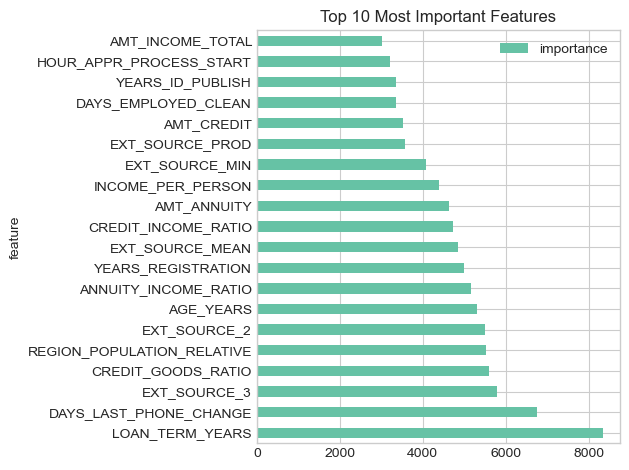

In [51]:
#check for the most important features
importance = pd.DataFrame({
    'feature':X_train.columns,
    'importance':lgb_model.feature_importances_}).sort_values('importance', ascending=False)

useful_features = importance[importance['importance']>0]['feature'].tolist()
X_train_selected = X_train[useful_features]
X_test_selected = X_test[useful_features]

plt.figure(figsize=(10, 8))
importance.head(20).plot.barh(x='feature', y='importance')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

In [52]:
from sklearn.model_selection import cross_val_score

cv_model = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.02, num_leaves=63, class_weight='balanced', random_state=42, n_jobs=-1, force_col_wise=True)
cv_scores = cross_val_score(cv_model, X,y, cv=5, scoring='roc_auc', n_jobs=1)
print(f'CV Scores : {cv_scores}')
print(f'Mean AUC : {cv_scores.mean():.4f}')
print(f'STD : {cv_scores.std():.4f}')

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 4298
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 4302
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 4304
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 144
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.00

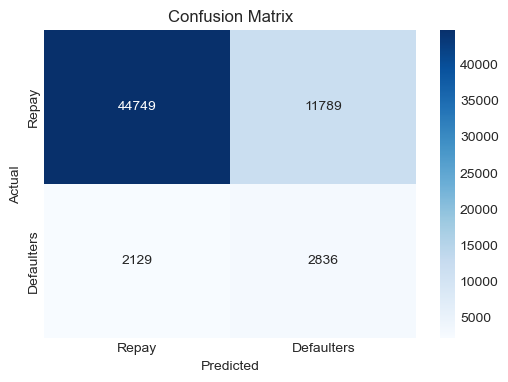

              precision    recall  f1-score   support

      Repaid       0.95      0.79      0.87     56538
   Defaulted       0.19      0.57      0.29      4965

    accuracy                           0.77     61503
   macro avg       0.57      0.68      0.58     61503
weighted avg       0.89      0.77      0.82     61503



In [53]:
from sklearn.metrics import confusion_matrix, classification_report

# Convert probabilities to hard predictions using 0.5 threshold
y_pred = (y_pred_proba >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Repay', 'Defaulters'], yticklabels=['Repay', 'Defaulters'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred, target_names=['Repaid', 'Defaulted']))

In [54]:
import joblib

# Step 2 — Create final model with best parameters
best_params = random_search.best_params_

final_model = lgb.LGBMClassifier(n_estimators=2000, learning_rate=best_params['learning_rate'], num_leaves=best_params['num_leaves'], min_child_samples=best_params['min_child_samples'],
    class_weight='balanced',random_state=42,n_jobs=-1, force_col_wise=True )

# Step 3 — Train final model
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)]
)

# Step 4 — Evaluate
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
final_auc    = roc_auc_score(y_test, y_pred_proba)
print(f'\nFinal Model AUC-ROC: {final_auc:.4f}')

# Step 5 — Save model and features together
joblib.dump(final_model, 'home_credit_model.pkl')
joblib.dump(X_train.columns.tolist(), 'feature_names.pkl')

print(f'\nModel expects  : {final_model.n_features_in_} features')
print(f'Features saved : {len(X_train.columns.tolist())} features')
print('Model and features saved successfully!')

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 4300
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 141
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.59142
[200]	valid_0's binary_logloss: 0.571327
[300]	valid_0's binary_logloss: 0.560398
[400]	valid_0's binary_logloss: 0.552204
[500]	valid_0's binary_logloss: 0.545073
[600]	valid_0's binary_logloss: 0.538388
[700]	valid_0's binary_logloss: 0.531815
[800]	valid_0's binary_logloss: 0.525585
[900]	valid_0's binary_logloss: 0.519936
[1000]	valid_0's binary_logloss: 0.514135
[1100]	valid_0's binary_logloss: 0.508606
[1200]	valid_0's binary_logloss: 0.503279
[1300]	valid_0's binary_logloss: 0.498273
[1400]	valid_0's binary_logloss: 0.493342
[1500]	valid_0's binary_l

### CONCLUSION

🏢 The Company — Home Credit Group
Home Credit B.V. is an international non-bank financial institution founded in 1997 in the Czech Republic and headquartered in the Netherlands. The company operates in 9 countries and focuses on installment lending primarily to people with little or no credit history. Wikipedia
Industry: Consumer Finance / Fintech,
Their responsible lending model empowers underserved customers with little or no credit history to access financing, enabling customers to borrow easily and safely, both online and offline. Homecredit
Founded with just 33 employees, their Home Credit family numbers more than 44,000 employees today, and they have served over 144 million customers across 9 different markets.
Why they built this dataset: Home Credit hosted the competition on Kaggle asking the data science community to help answer the big question — "How likely is it a client will repay a loan?" — looking for solutions to drive more sustainable loan decision-making. We this i started by analysing my dataset, then visualize it to get more insight and i balanced the data with smote and train all the model that i used which include lightLGB, LogisticRegression and RandomForest, then i used AUC-ROC to get my final score for it. and i deployed it in FastAPI to make final prediction which is live on render about how likely is it that a client will repay a loan and i also hosted it on frontend website in netlify to also make prediction about how risky it is, that an applicant will repay or default.
The best model which we used for prediction lightgbm_model with the higheset AUC_ROC of 0.7518 score